In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV, VarianceThreshold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
import shap
solar = pd.read_csv('solar_combined.csv')

solar.info()
print("Total number of molecules in the dataset is: ", len(solar.index))
missing_values = solar.isnull().sum().sum()
print("Are there missing values? Answer:", "No" if missing_values == 0 else "Yes")


#KS_gap=E_lumo - E_homo
solar['xyz'] = solar['E_lumo'] - solar['E_homo']
print(solar[['KS_gap', 'xyz']].corr())

#will use smiles descriptors as features
#using smiles to get molecule descriptors
ALL_DESCRIPTORS = Descriptors._descList  # list of (name, function) pairs


def featurize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    values = []
    for name, func in ALL_DESCRIPTORS:
        try:
            values.append(func(mol))
        except Exception:
            values.append(np.nan)
    return values


print("\nFeaturizing molecules from SMILES")
feature_rows, valid_idx = [], []
for i, smi in enumerate(solar['CAN_SMILES']):
    vec = featurize(smi)
    if vec is not None:
        feature_rows.append(vec)
        valid_idx.append(i)

desc_cols = [name for name, _ in ALL_DESCRIPTORS]
X_desc = pd.DataFrame(feature_rows, columns=desc_cols, index=valid_idx)

/Users/anuradhasambyal/PyCharmMiscProject/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5366 entries, 0 to 5365
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          5366 non-null   int64  
 1   unique_id   5366 non-null   object 
 2   formula     5366 non-null   object 
 3   natoms      5366 non-null   int64  
 4   volume      5366 non-null   float64
 5   mass        5366 non-null   float64
 6   charge      5366 non-null   float64
 7   pbc         5366 non-null   object 
 8   rho         5366 non-null   float64
 9   SMILES      5366 non-null   object 
 10  Energy      5366 non-null   float64
 11  CAN_SMILES  5366 non-null   object 
 12  Name        5366 non-null   object 
 13  E_lumo      5366 non-null   float64
 14  InChI       5366 non-null   object 
 15  E_homo      5366 non-null   float64
 16  KS_gap      5366 non-null   float64
 17  Unit        5366 non-null   object 
 18  dip         5366 non-null   float64
 19  E_opt       3592 non-null  

[16:02:27] Explicit valence for atom # 4 N, 4, is greater than permitted
[16:02:28] Explicit valence for atom # 20 N, 4, is greater than permitted
[16:03:02] Explicit valence for atom # 7 N, 4, is greater than permitted
[16:03:02] Explicit valence for atom # 11 N, 4, is greater than permitted
[16:03:02] Explicit valence for atom # 18 N, 4, is greater than permitted
[16:03:04] Explicit valence for atom # 18 N, 4, is greater than permitted
[16:03:06] Explicit valence for atom # 20 N, 4, is greater than permitted
[16:03:43] Explicit valence for atom # 19 N, 4, is greater than permitted
[16:03:43] Explicit valence for atom # 13 N, 4, is greater than permitted
[16:03:44] Explicit valence for atom # 20 N, 4, is greater than permitted


In [3]:
print(X_desc.head())

   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0          18.748297       18.748297           0.013781       -0.929466   
1          20.197488       20.197488           0.004840       -1.034663   
2          20.233472       20.233472           0.260013       -0.433270   
3          19.322766       19.322766           0.253671       -0.415044   
4          18.594639       18.594639           0.068928       -0.492269   

        qed        SPS     MolWt  HeavyAtomMolWt   ExactMolWt  \
0  0.044663  12.000000  2074.518        2010.006  2072.078566   
1  0.025862  12.021978  2727.322        2614.426  2724.411827   
2  0.040088  12.280488  2507.518        2400.670  2504.337720   
3  0.035647  12.000000  2024.800        1934.080  2022.300939   
4  0.056745  12.315789  1812.602        1742.042  1810.108922   

   NumValenceElectrons  ...  fr_sulfide  fr_sulfonamd  fr_sulfone  \
0                  682  ...           4             0           0   
1                  9

In [4]:
#will not use any dft calculated energy as feature
#will use X_desc as feature column
target_vars = ['KS_gap', 'E_opt']
data = X_desc.copy()
for t in target_vars:
    data[t] = solar.loc[valid_idx, t].values


TARGET: KS_gap
Rows available for this target: 5356
After removing near-constant descriptors: 129 left (started with 217)


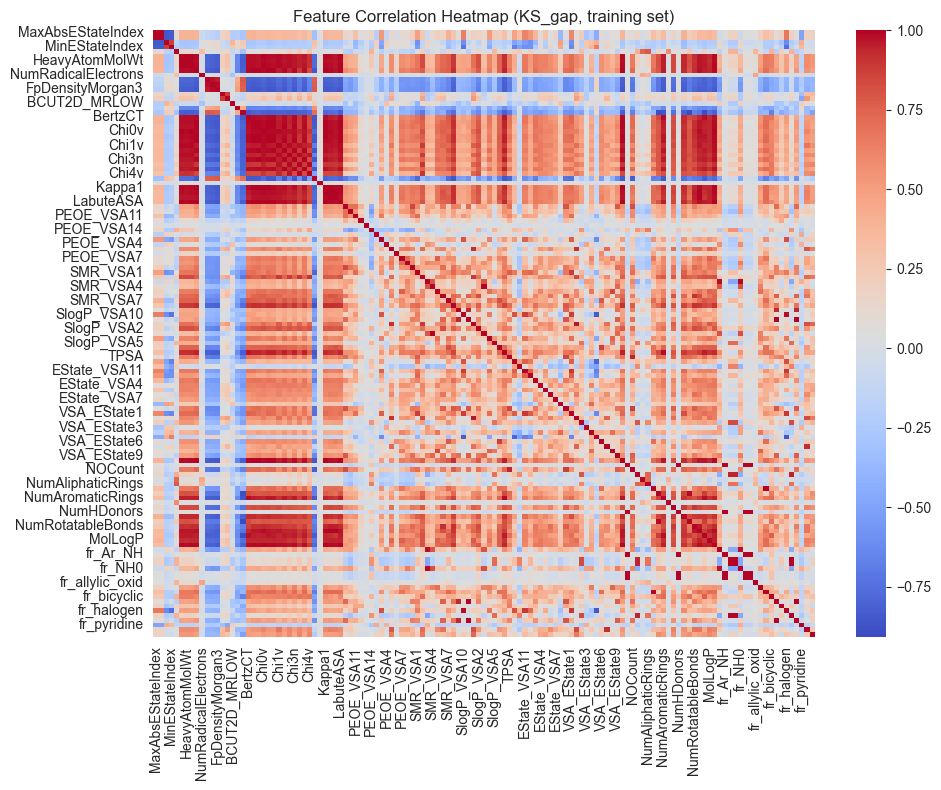

Highly correlated descriptors removed: 54
Remaining descriptors: 75
Optimal number of features: 75
Selected features: ['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'SPS', 'MolWt', 'NumRadicalElectrons', 'FpDensityMorgan1', 'BCUT2D_MWHI', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'HallKierAlpha', 'Ipc', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA2', 'SlogP_VSA4', 'SlogP_VSA5', 'SlogP_VSA6', 'TPSA', 'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'VSA_EState1', 'VSA_EState2', 'VSA_EState3', 'VSA_EState4', 'VSA_EState5', 'VSA_EState6', 'VSA_EState7', 'VSA_EState8', 'VSA_EState9', 'NHOHCount', 'Nu

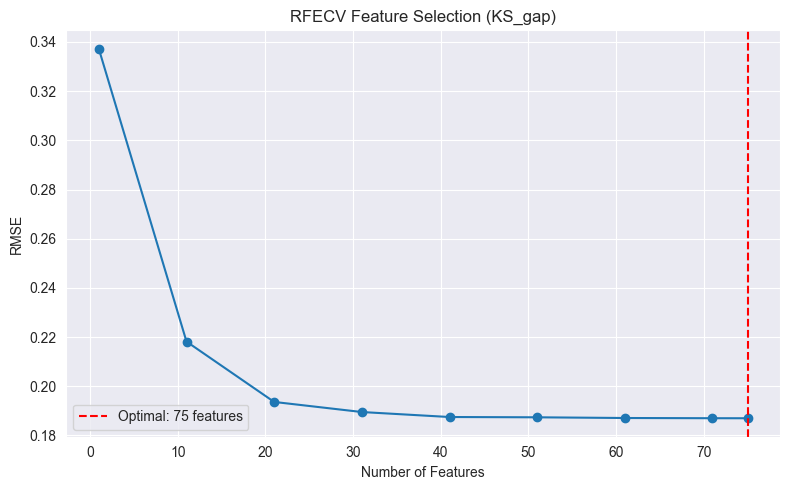


TARGET: E_opt
Rows available for this target: 3582
After removing near-constant descriptors: 128 left (started with 217)


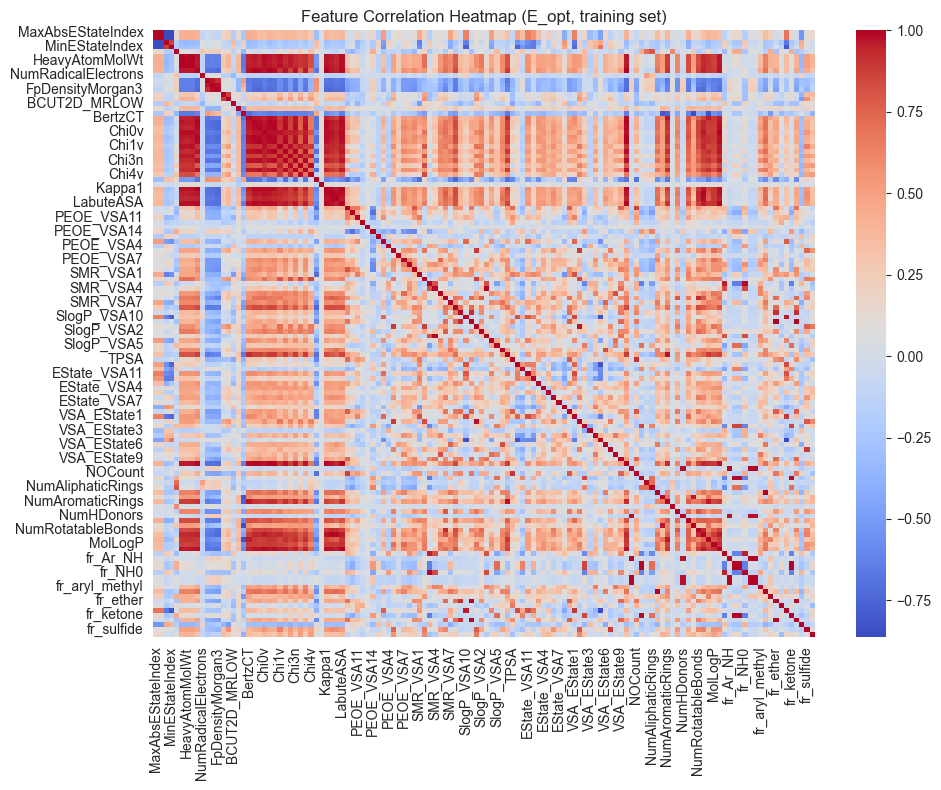

Highly correlated descriptors removed: 49
Remaining descriptors: 79
Optimal number of features: 49
Selected features: ['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'SPS', 'MolWt', 'BCUT2D_MWHI', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA6', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA10', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA9', 'SlogP_VSA4', 'SlogP_VSA5', 'SlogP_VSA6', 'TPSA', 'EState_VSA2', 'EState_VSA4', 'EState_VSA5', 'EState_VSA7', 'EState_VSA8', 'VSA_EState2', 'VSA_EState3', 'VSA_EState4', 'VSA_EState5', 'VSA_EState6', 'VSA_EState7', 'VSA_EState8', 'VSA_EState9', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'fr_bicyclic', 'fr_furan', 'fr_pyridine', 'fr_sulfide']


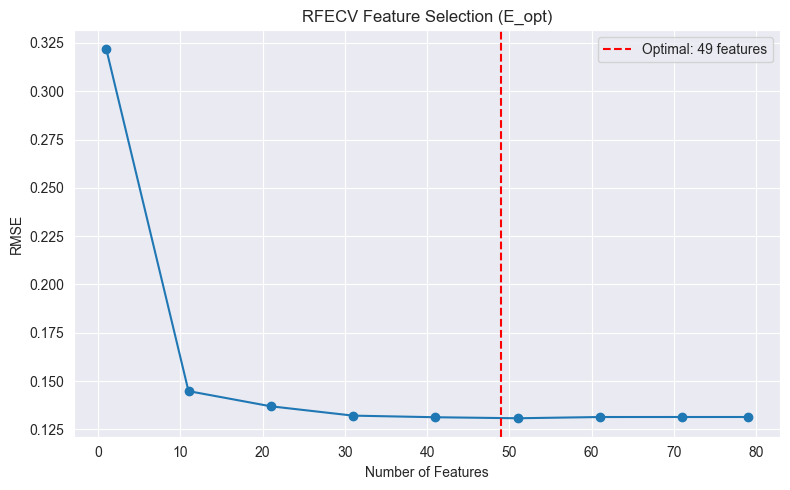

In [5]:
from sklearn.model_selection import GridSearchCV

def run_pipeline(target_name, corr_threshold=0.9, cv_folds=5, rfecv_step=10):
    print(f"\n{'='*60}\nTARGET: {target_name}\n{'='*60}")

    df = data.dropna(subset=[target_name])
    X = df[desc_cols].replace([np.inf, -np.inf], np.nan)
    y = df[target_name]
    print(f"Rows available for this target: {len(df)}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    train_medians = X_train.median(numeric_only=True)
    X_train = X_train.fillna(train_medians)
    X_test = X_test.fillna(train_medians)

    var_selector = VarianceThreshold(threshold=0.01)
    X_train_var = pd.DataFrame(
        var_selector.fit_transform(X_train),
        columns=X_train.columns[var_selector.get_support()],
        index=X_train.index,
    )
    X_test_var = pd.DataFrame(
        var_selector.transform(X_test),
        columns=X_train_var.columns,
        index=X_test.index,
    )
    print(f"After removing near-constant descriptors: {X_train_var.shape[1]} left "
          f"(started with {X_train.shape[1]})")

    corr_matrix = X_train_var.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
    plt.title(f'Feature Correlation Heatmap ({target_name}, training set)')
    plt.tight_layout()
    plt.show()

    high_corr = set()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) >= corr_threshold:
                high_corr.add(corr_matrix.columns[i])
                break
    print(f'Highly correlated descriptors removed: {len(high_corr)}')
    X_train_reduced = X_train_var.drop(columns=high_corr)
    X_test_reduced = X_test_var.drop(columns=high_corr)
    print(f"Remaining descriptors: {X_train_reduced.shape[1]}")

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_reduced),
        columns=X_train_reduced.columns, index=X_train_reduced.index,
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_reduced),
        columns=X_test_reduced.columns, index=X_test_reduced.index,
    )

    #RFECV
    estimator = GradientBoostingRegressor(n_estimators=100, random_state=42)
    rfecv = RFECV(estimator=estimator, step=rfecv_step, cv=KFold(cv_folds),
                  scoring='neg_mean_squared_error', n_jobs=-1)
    rfecv.fit(X_train_scaled, y_train)
    print("Optimal number of features:", rfecv.n_features_)
    selected = list(X_train_scaled.columns[rfecv.support_])
    print("Selected features:", selected)

    #RFECV plot
    rmse_scores = np.sqrt(-rfecv.cv_results_['mean_test_score'])
    n_total_features = X_train_scaled.shape[1]
    feature_counts = [1 + i * rfecv_step if 1 + i * rfecv_step < n_total_features else n_total_features
                       for i in range(len(rmse_scores))]

    plt.figure(figsize=(8, 5))
    plt.plot(feature_counts, rmse_scores, marker='o')
    plt.axvline(rfecv.n_features_, color='red', linestyle='--',
                label=f'Optimal: {rfecv.n_features_} features')
    plt.xlabel("Number of Features")
    plt.ylabel("RMSE")
    plt.title(f"RFECV Feature Selection ({target_name})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


models_by_target = {}
for target in target_vars:
    models_by_target[target] = run_pipeline(target)